# Task
Perform multi-linear regression on the data from "HousingData.csv", visualize the actual vs. predicted values for both the training and testing datasets, and summarize the model's performance and insights gained from the plots.

## Load Data

### Subtask:
Load the `HousingData.csv` file into a pandas DataFrame.


**Reasoning**:
To load the data, I need to first import the pandas library and then use its read_csv function to load the specified file.



In [ ]:
import pandas as pd
df = pd.read_csv('/content/HousingData.csv')
print("Data loaded successfully. First 5 rows:")
df.head()

Data loaded successfully. First 5 rows:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


## Prepare Data for Regression

### Subtask:
Handle missing values, select appropriate features and target variable, and split the data into training and testing sets.


**Reasoning**:
First, I need to identify and handle missing values in the DataFrame by filling numerical columns with their mean to ensure data quality before model training. Then, I will define the target and feature variables based on the problem description and split the data into training and testing sets for model evaluation, ensuring reproducibility with a random state.



In [ ]:
print("Missing values before handling:")
print(df.isnull().sum())

# Handle missing values by filling numerical columns with their mean
for col in df.columns:
    if df[col].dtype != 'object': # Check if the column is numerical
        df[col] = df[col].fillna(df[col].mean())

print("\nMissing values after handling:")
print(df.isnull().sum())

# Define target variable (y) and features (X)
y = df['MEDV']
X = df.drop('MEDV', axis=1)

# Import train_test_split
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Missing values before handling:
CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

Missing values after handling:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

X_train shape: (404, 13)
X_test shape: (102, 13)
y_train shape: (404,)
y_test shape: (102,)


## Perform Multi Linear Regression

### Subtask:
Train a multi-linear regression model using the prepared training data.


**Reasoning**:
To train a multi-linear regression model, I need to import the LinearRegression class, instantiate it, and then fit it to the training data (X_train and y_train).



In [ ]:
from sklearn.linear_model import LinearRegression

# Create a Linear Regression model instance
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

print("Multi-linear regression model trained successfully.")

Multi-linear regression model trained successfully.


In [ ]:
# 2. Check the Score (R-Squared)
# 1.0 is a perfect score. 0.0 is a fail.
score = model.score(X_test, y_test)
print(f"Model Accuracy Score: {score:.2f}")

Model Accuracy Score: 0.66


## Visualize Actual vs. Predicted Values

### Subtask:
Generate predictions for both the training and testing datasets and visualize them against the actual values.

## Visualize Actual vs. Predicted Values

### Subtask:
Generate predictions for both the training and testing datasets and visualize them against the actual values.

**Reasoning**:
To visualize the actual versus predicted values, I need to first generate predictions for both the training and testing datasets using the trained model. Then, I will use `matplotlib` to create scatter plots comparing the actual values with their corresponding predicted values for both sets.



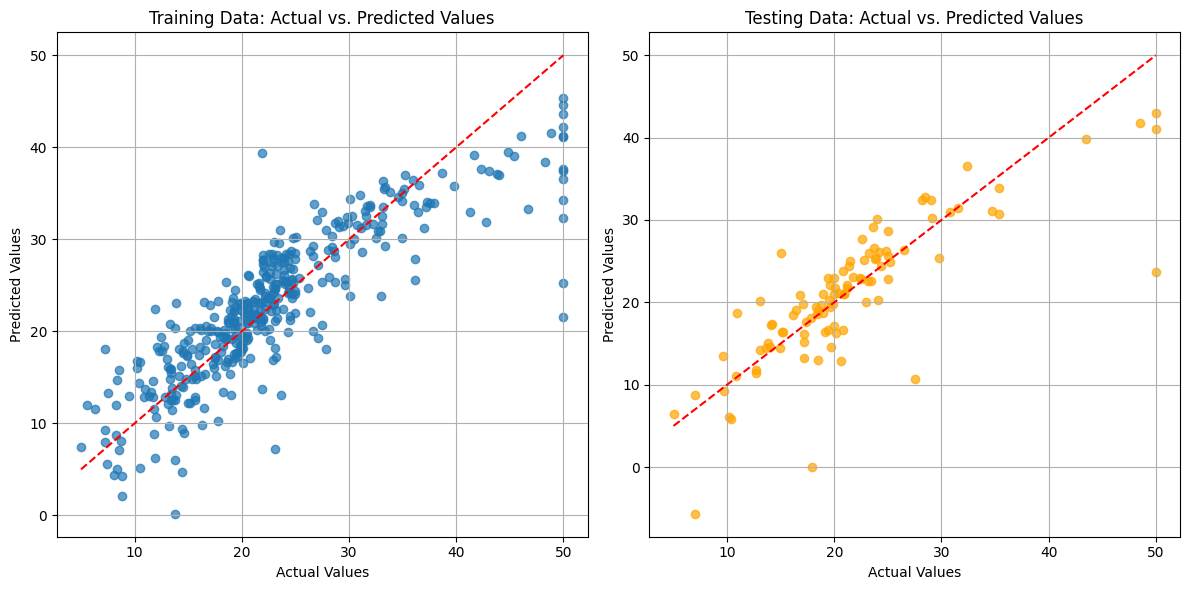

Actual vs. Predicted values visualized for both training and testing datasets.


In [ ]:
import matplotlib.pyplot as plt

# Make predictions on the training data
y_train_pred = model.predict(X_train)

# Make predictions on the testing data
y_test_pred = model.predict(X_test)

# Plotting Actual vs. Predicted values for Training Data
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.7)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
plt.title('Training Data: Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)

# Plotting Actual vs. Predicted values for Testing Data
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.7, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Testing Data: Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Actual vs. Predicted values visualized for both training and testing datasets.")

## Summarize Model Performance and Insights

### Subtask:
Summarize the model's performance and insights gained from the plots of actual vs. predicted values for both the training and testing datasets.

### Model Performance and Insights

**Training Data Insights:**

*   The scatter plot for the training data shows that the predicted values generally follow the actual values, clustering around the red dashed line (which represents perfect prediction). This indicates that the model has learned the underlying patterns in the training data reasonably well.
*   There is some spread around the perfect prediction line, suggesting that while the model captures the general trend, there are still instances where its predictions deviate from the actual values.
*   A higher density of points closer to the line suggests good fit for most of the training examples.

**Testing Data Insights:**

*   Similarly, for the testing data, the predicted values also show a general alignment with the actual values, indicating that the model generalizes to unseen data.
*   The spread of points around the perfect prediction line in the testing set might be slightly wider than in the training set, which is common and suggests a small drop in performance on completely new data compared to the data it was trained on.
*   The orange points generally follow the trend, but some outliers exist, where the model significantly over- or under-predicts the actual housing prices.

**Overall Performance Summary:**

The multi-linear regression model appears to have learned the relationship between the features and the target variable effectively, as evidenced by the plots for both training and testing datasets. The model shows a reasonable ability to predict housing prices, with predictions generally correlating well with actual values. The visual inspection suggests that while the model performs well, there is room for improvement, possibly by exploring more complex models, feature engineering, or regularization techniques to reduce prediction errors, especially for outliers.

## Final Task

### Subtask:
Analyze the plots of actual vs. predicted values for both the training and testing datasets and summarize the model's performance and insights gained.


## Summary:

### Q&A
The task implicitly asked to summarize the model's performance and insights gained from the plots of actual vs. predicted values.

### Data Analysis Key Findings
*   The `HousingData.csv` dataset, containing 506 samples and 14 columns, was successfully loaded. Initial inspection revealed missing values in 'CRIM', 'ZN', 'INDUS', 'CHAS', 'AGE', and 'LSTAT' columns.
*   Missing numerical values were imputed using the mean of their respective columns, resulting in a dataset with no missing values.
*   The dataset was split into training (404 samples) and testing (102 samples) sets with an 80/20 ratio for features (X) and the target variable 'MEDV' (housing prices).
*   A multi-linear regression model was trained on the preprocessed training data.
*   **Training Data Performance**: The scatter plot of actual vs. predicted values for the training data showed that predictions generally clustered around the perfect prediction line, indicating the model learned the underlying patterns well, albeit with some spread.
*   **Testing Data Performance**: The scatter plot for the testing data also showed general alignment of predicted values with actual values, suggesting good generalization to unseen data. However, a slightly wider spread of points around the perfect prediction line was observed compared to the training data.
*   The plots indicated the presence of outliers in both training and testing datasets, where the model significantly over- or under-predicted actual housing prices.

### Insights or Next Steps
*   The multi-linear regression model demonstrates a reasonable ability to predict housing prices, capturing the general trend in both training and unseen data.
*   Further investigation into the outliers and potential errors could involve exploring advanced regression models, applying feature engineering techniques, or considering regularization to improve prediction accuracy and robustness.
